In [ ]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from IPython.display import Image
from io import StringIO
from IPython.display import Image
import graphviz
import pydotplus
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

In [ ]:
wine = load_wine()
wine_X = wine.data[:, :2]
wine_y = wine.target

In [ ]:
def make_meshgrid(x, y, h=.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy

def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    #Можно проверить все ли метки классов предсказываются
    #print(np.unique(Z))
    out = ax.contourf(xx, yy, Z, **params)
    return out


def plot_cl(clf):
    title = clf.__repr__
    clf.fit(wine_X, wine_y)
    fig, ax = plt.subplots(figsize=(5,5))
    X0, X1 = wine_X[:, 0], wine_X[:, 1]
    xx, yy = make_meshgrid(X0, X1)
    plot_contours(ax, clf, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=wine_y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel('alcohol')
    ax.set_ylabel('ash')
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)
    plt.show()

In [ ]:
from operator import itemgetter

def draw_feature_importances(tree_model, X_dataset, figsize=(10,5)):
    """
    Вывод важности признаков в виде графика
    """
    # Сортировка значений важности признаков по убыванию
    list_to_sort = list(zip(X_dataset.columns.values, tree_model.feature_importances_))
    sorted_list = sorted(list_to_sort, key=itemgetter(1), reverse = True)
    # Названия признаков
    labels = [x for x,_ in sorted_list]
    # Важности признаков
    data = [x for _,x in sorted_list]
    # Вывод графика
    fig, ax = plt.subplots(figsize=figsize)
    ind = np.arange(len(labels))
    plt.bar(ind, data)
    plt.xticks(ind, labels, rotation='vertical')
    # Вывод значений
    for a,b in zip(ind, data):
        plt.text(a-0.05, b+0.01, str(round(b,3)))
    plt.show()
    return labels, data

In [ ]:
def get_png_tree(tree_model_param, feature_names_param):
    dot_data = StringIO()
    export_graphviz(tree_model_param, out_file=dot_data, feature_names=feature_names_param,
                    filled=True, rounded=True, special_characters=True)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    return graph.create_png()

In [ ]:
   def accuracy_score_for_classes(
    y_true: np.ndarray,
    y_pred: np.ndarray) -> Dict[int, float]:
    """
    Вычисление метрики accuracy для каждого класса
    y_true - истинные значения классов
    y_pred - предсказанные значения классов
    Возвращает словарь: ключ - метка класса,
    значение - Accuracy для данного класса
    """
    # Для удобства фильтрации сформируем Pandas DataFrame
    d = {'t': y_true, 'p': y_pred}
    df = pd.DataFrame(data=d)
    # Метки классов
    classes = np.unique(y_true)
    # Результирующий словарь
    res = dict()
    # Перебор меток классов
    for c in classes:
        # отфильтруем данные, которые соответствуют
        # текущей метке класса в истинных значениях
        temp_data_flt = df[df['t']==c]
        # расчет accuracy для заданной метки класса
        temp_acc = accuracy_score(
            temp_data_flt['t'].values,
            temp_data_flt['p'].values)
        # сохранение результата в словарь
        res[c] = temp_acc
    return res

def print_accuracy_score_for_classes(
    y_true: np.ndarray,
    y_pred: np.ndarray):
    """
    Вывод метрики accuracy для каждого класса
    """
    accs = accuracy_score_for_classes(y_true, y_pred)
    if len(accs)>0:
        print('Метка \t Accuracy')
    for i in accs:
        print('{} \t {}'.format(i, accs[i]))

In [ ]:
ab1 = AdaBoostClassifier(n_estimators=5, algorithm='SAMME', random_state=10)
ab1.fit(wine_X, wine_y)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoostClassifier(algorithm='SAMME', n_estimators=5, random_state=10)

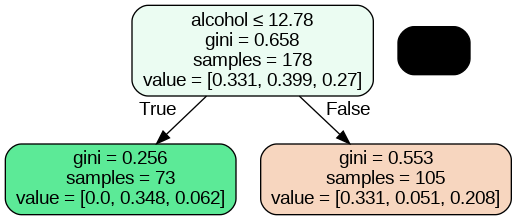

In [ ]:
Image(get_png_tree(ab1.estimators_[0], wine.feature_names[:2]), width='40%')

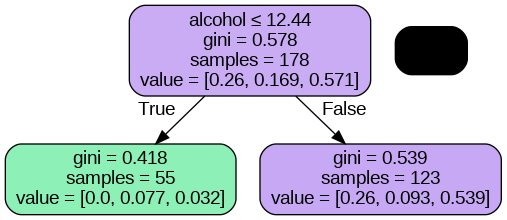

In [ ]:
Image(get_png_tree(ab1.estimators_[3], wine.feature_names[:2]), width='40%')

In [ ]:
df1 = ab1.decision_function(wine_X)
df1.shape

(178, 3)

In [ ]:
df1[:10]

array([[ 0.33832685, -0.12154681, -0.21678004],
       [ 0.33832685, -0.12154681, -0.21678004],
       [ 0.33832685, -0.5       ,  0.16167315],
       [ 0.33832685, -0.12154681, -0.21678004],
       [ 0.33832685, -0.5       ,  0.16167315],
       [ 0.33832685, -0.12154681, -0.21678004],
       [ 0.33832685, -0.12154681, -0.21678004],
       [ 0.33832685, -0.12154681, -0.21678004],
       [ 0.33832685, -0.12154681, -0.21678004],
       [ 0.33832685, -0.12154681, -0.21678004]])

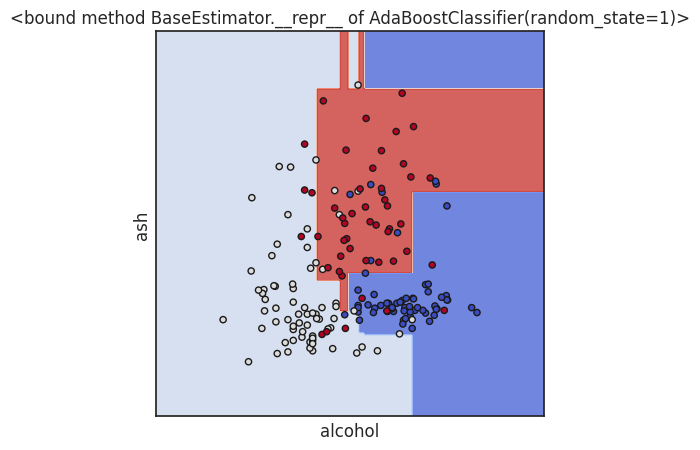

In [ ]:
plot_cl(AdaBoostClassifier(random_state=1))

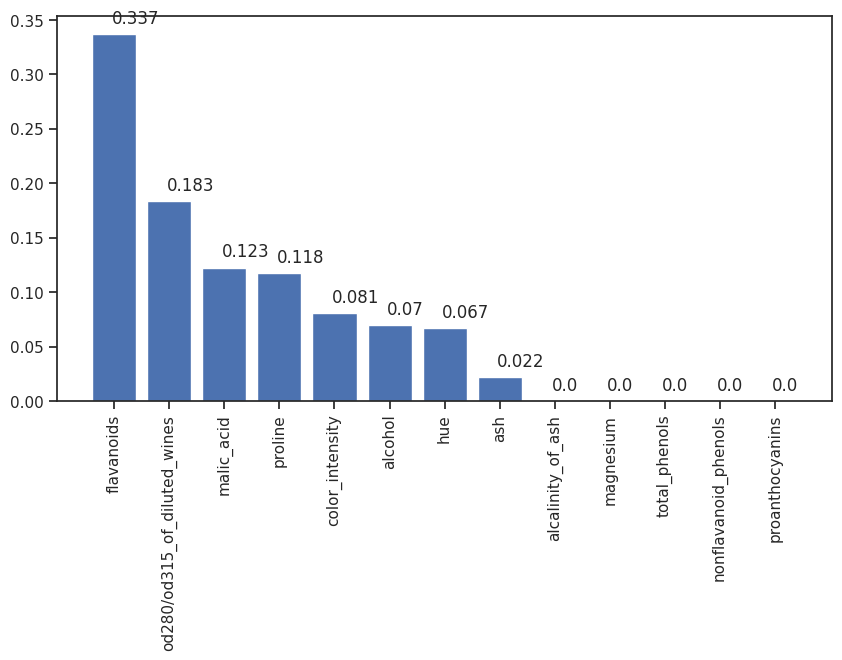

In [ ]:
wine_x_ds = pd.DataFrame(data=wine['data'], columns=wine['feature_names'])
ab2 = AdaBoostClassifier(random_state=1)
ab2.fit(wine_x_ds, wine.target)
_,_ = draw_feature_importances(ab2, wine_x_ds)

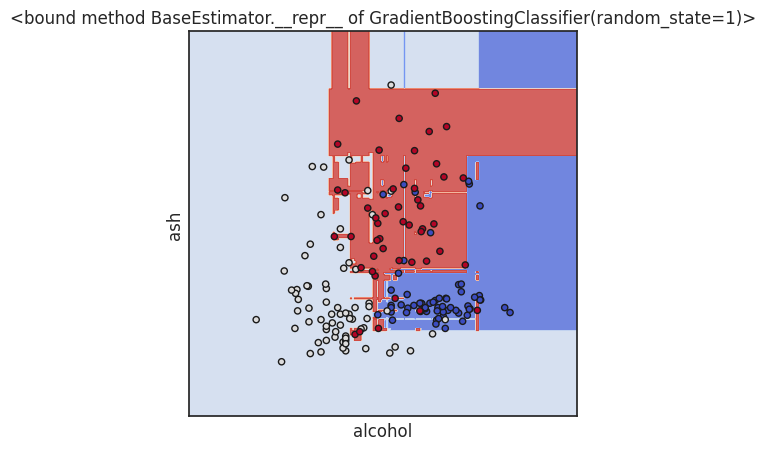

In [ ]:
plot_cl(GradientBoostingClassifier(random_state=1))

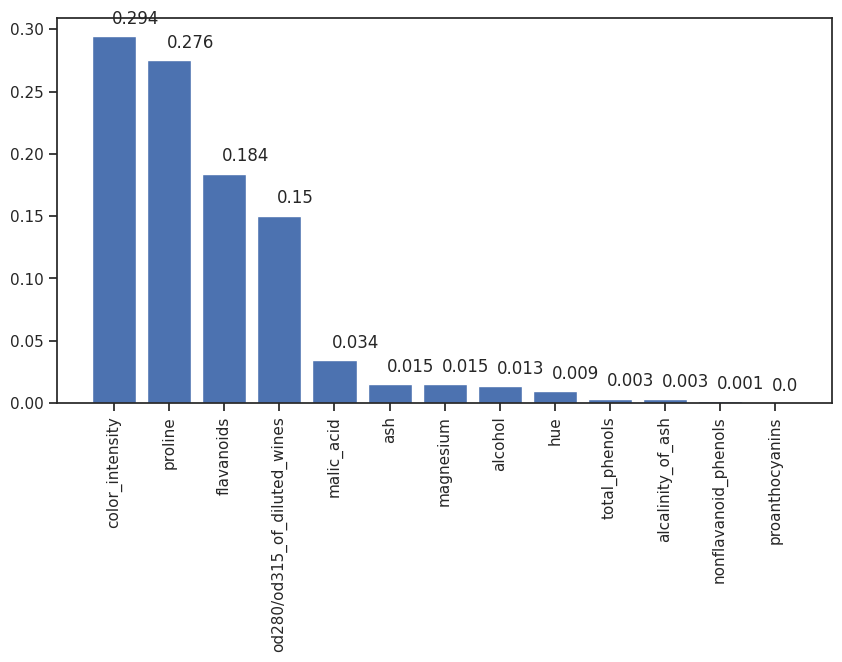

In [ ]:
wine_gb_cl = GradientBoostingClassifier(random_state=1)
wine_gb_cl.fit(wine_x_ds, wine.target)
_,_ = draw_feature_importances(wine_gb_cl, wine_x_ds)

In [ ]:
bc1 = BaggingClassifier(n_estimators=5, oob_score=True, random_state=10)
bc1.fit(wine_X, wine_y)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:865: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:871: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


BaggingClassifier(n_estimators=5, oob_score=True, random_state=10)

In [ ]:
bc1.estimators_samples_

[array([165, 137, 177, 103, 142, 138,  26, 152, 138,  50, 172, 126,  67,
         34,  24,  43, 149,  58, 112, 118, 104,  46, 104,  27,  74, 147,
         37,  45, 132,  44, 142,  69, 156,  74,  23, 167, 108,  64, 171,
          0,  50, 150,  78, 171,  42, 112,  77, 156,  50,   4, 114,  14,
         56, 170, 105,  43,  39,  43, 139,  80, 176, 127, 159, 116,  56,
         54, 110, 138, 136,   4,  79,  62,  44,  60, 111,  74, 153, 114,
        125, 137, 102, 153,  88,  14, 130, 107, 110, 175, 118,  41, 151,
        174,  62,  66,  37,  14,  52, 120, 117, 171,  68, 176, 171,  73,
         39, 104,  92, 150,  44, 139, 165,  22, 167,  66, 163, 107, 171,
         27, 153,  85,  54,  40, 146,  95,  38, 168,  92,  97,  61, 116,
         73, 116,  68,  48,  20, 124,  82,  37,  58, 101,   7, 123, 141,
        146,  38, 116, 105,  91, 163,   7,   0, 131,   3,  22, 167,  59,
        133,  20, 106, 162, 123,  11, 121,  66,  18,  46,  52, 147, 160,
         62,  89,  86,  37, 115, 132,  38,  90,  84

In [ ]:
bin_array = np.zeros((5, wine_X.shape[0]))
for i in range(5):
    for j in bc1.estimators_samples_[i]:
        bin_array[i][j] = 1
bin_array

array([[1., 0., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0.,
        0., 0., 1., 0., 1., 0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.,
        1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 1., 1., 1., 1., 0.,
        1., 0., 1., 1., 1., 1., 0., 0., 0., 1., 1., 0., 0., 1., 1., 1.,
        1., 0., 1., 0., 1., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1.,
        0., 1., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
        1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1.,
        0., 0., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 1., 1., 0.,
        0., 0., 1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0., 0., 1.,
        1., 0., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 0., 1., 1.,
        1., 1.],
       [1., 0., 1., 0., 1., 0., 0., 1., 1., 0., 1., 1., 0., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 0., 1.,
        0., 1., 1., 1., 1., 1., 1., 1., 0., 1.,

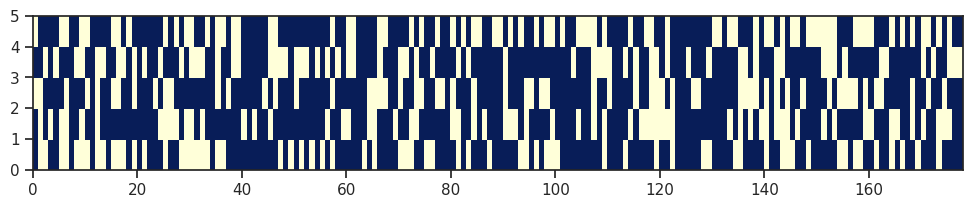

In [ ]:
fig, ax = plt.subplots(figsize=(12,2))
ax.pcolor(bin_array, cmap='YlGnBu')
plt.show()

In [ ]:
for i in range(5):
    cur_data = bin_array[i]
    len_cur_data = len(cur_data)
    sum_cur_data = sum(cur_data)
    (len(bin_array[0]) - sum(bin_array[0])) / len(bin_array[0])
    oob_i = (len_cur_data - sum_cur_data) / len_cur_data
    print('Для модели № {} размер OOB составляет {}%'.format(i+1, round(oob_i, 4)*100.0))

Для модели № 1 размер OOB составляет 37.64%
Для модели № 2 размер OOB составляет 35.96%
Для модели № 3 размер OOB составляет 34.27%
Для модели № 4 размер OOB составляет 37.08%
Для модели № 5 размер OOB составляет 42.13%


In [ ]:
bc1.oob_score_, 1-bc1.oob_score_

(0.7528089887640449, 0.2471910112359551)

In [ ]:
bc1.oob_decision_function_[55:70]

array([[1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [0.66666667, 0.        , 0.33333333],
       [1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.5       , 0.5       ],
       [       nan,        nan,        nan],
       [0.        , 1.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [       nan,        nan,        nan],
       [0.        , 1.        , 0.        ]])

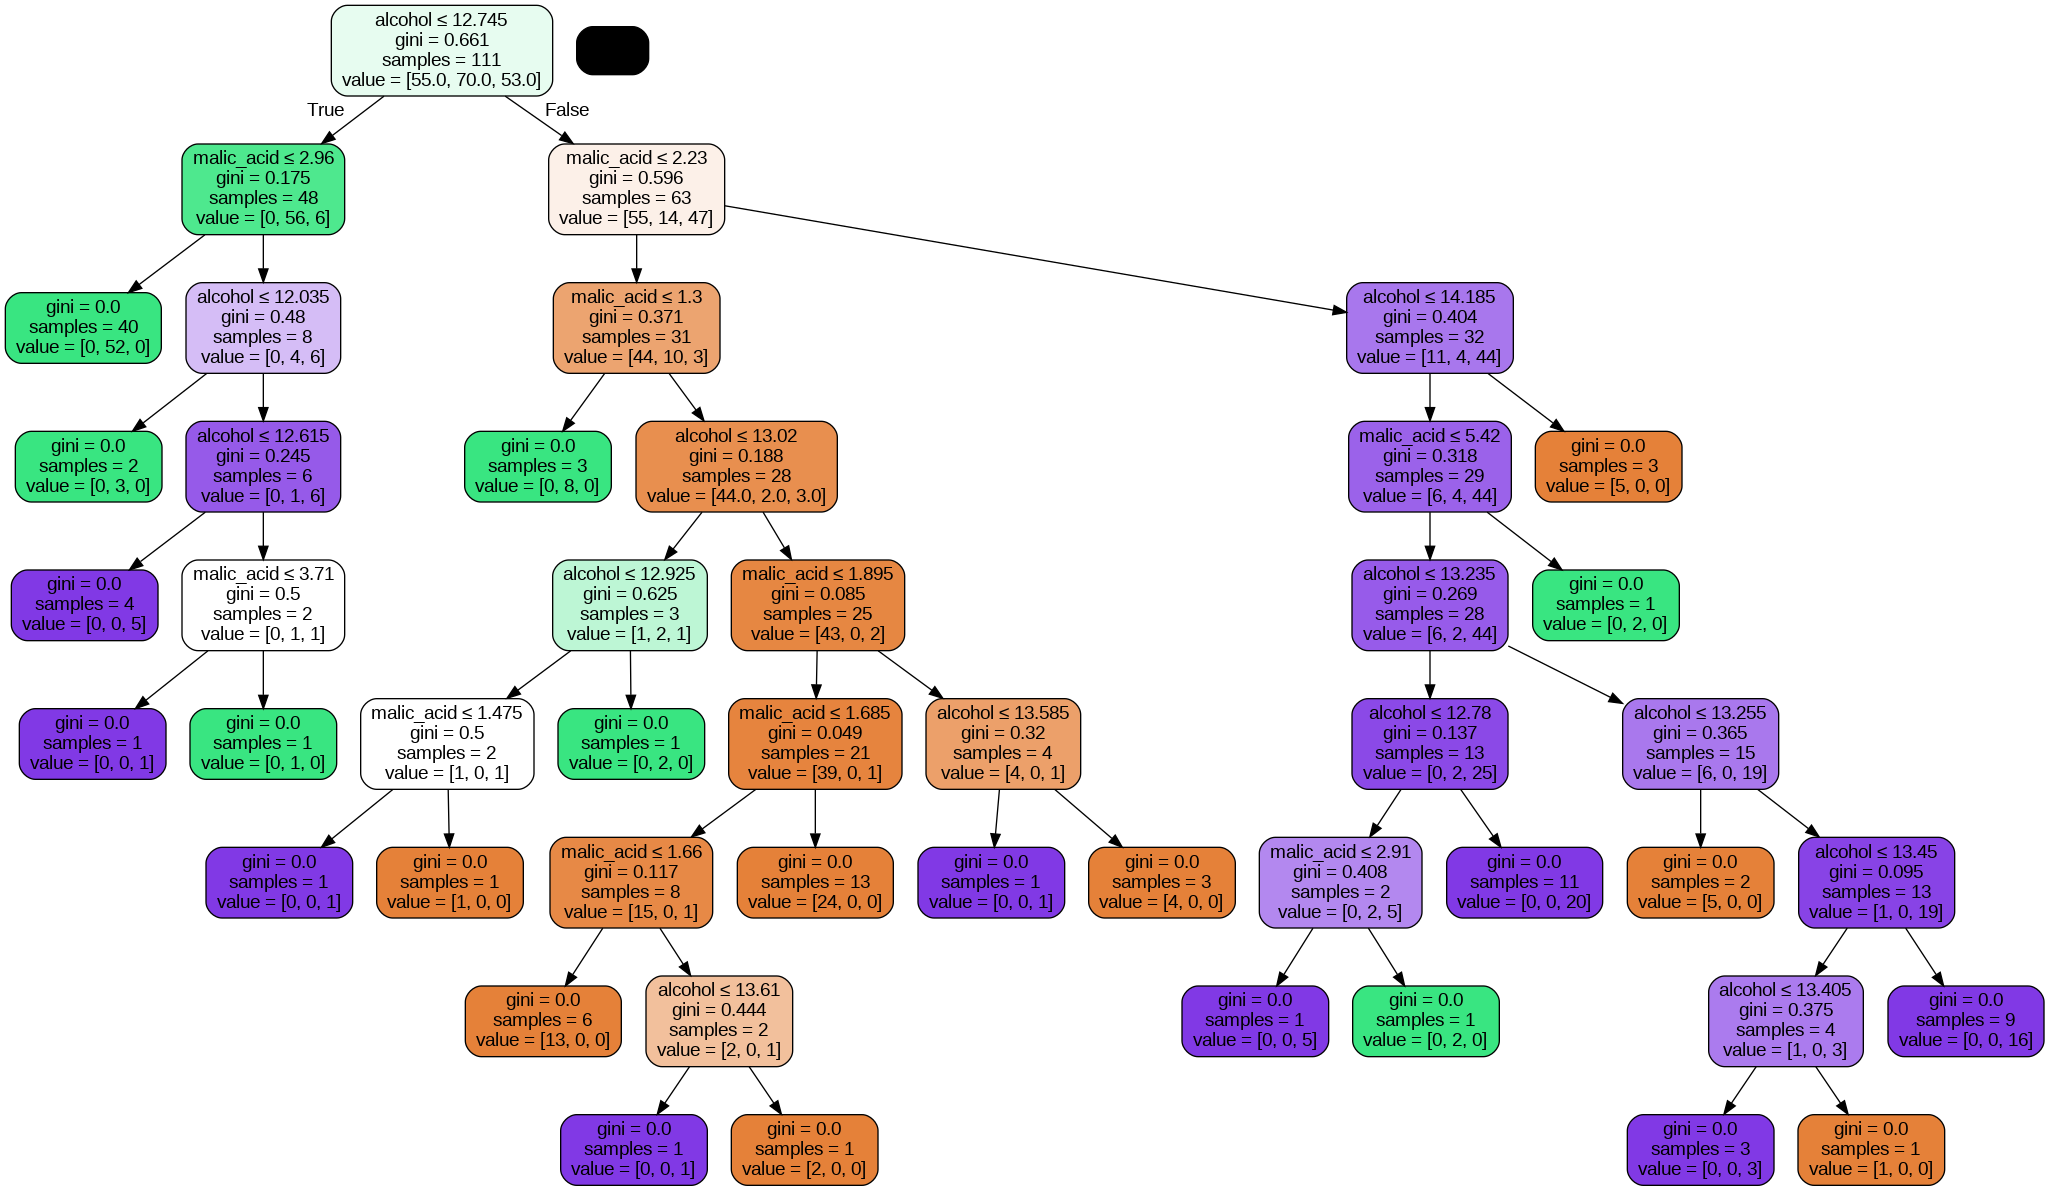

In [ ]:
Image(get_png_tree(bc1.estimators_[0], wine.feature_names[:2]), width='80%')

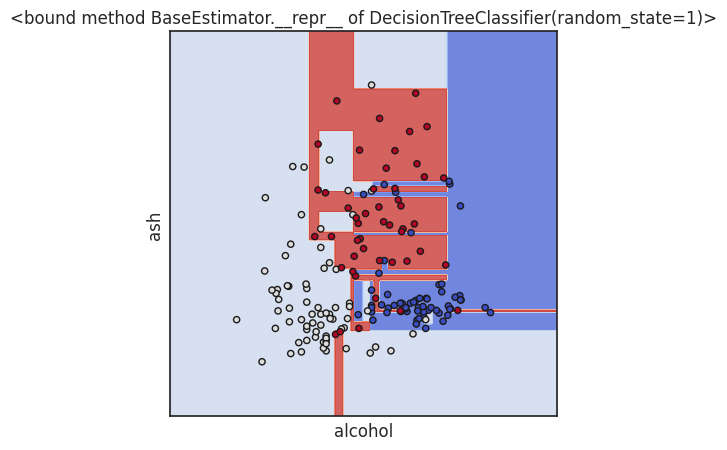

In [ ]:
plot_cl(DecisionTreeClassifier(random_state=1))

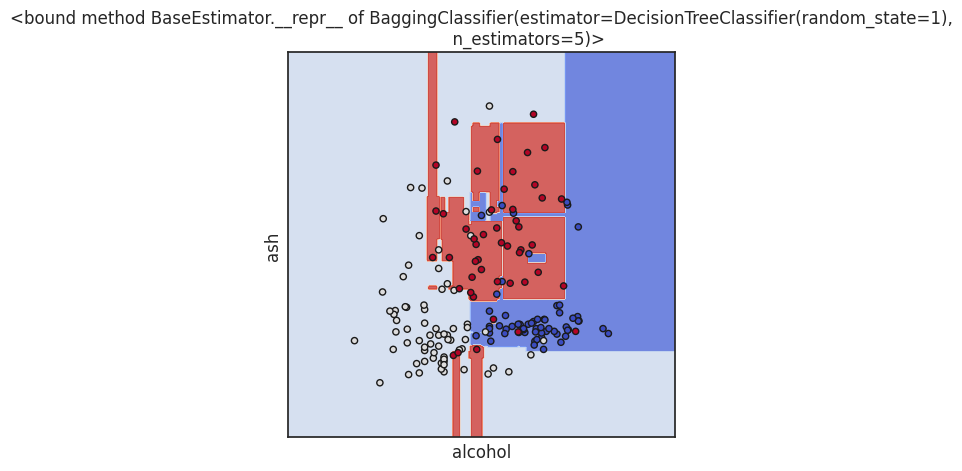

In [ ]:
plot_cl(BaggingClassifier(DecisionTreeClassifier(random_state=1), n_estimators=5))

In [ ]:
tree1 = RandomForestClassifier(n_estimators=5, oob_score=True, random_state=10)
tree1.fit(wine_X, wine_y)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


RandomForestClassifier(n_estimators=5, oob_score=True, random_state=10)

In [ ]:
tree1.oob_score_, 1-tree1.oob_score_

(0.7134831460674157, 0.2865168539325843)

In [ ]:
tree1.oob_decision_function_[55:70]

array([[1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.5       , 0.5       , 0.        ],
       [0.        , 0.66666667, 0.33333333],
       [0.        , 1.        , 0.        ],
       [0.        , 1.        , 0.        ],
       [0.        , 0.        , 0.        ],
       [0.        , 1.        , 0.        ]])

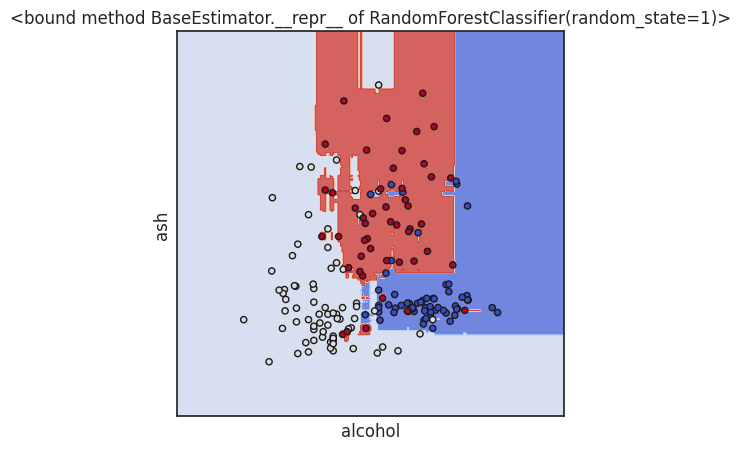

In [ ]:
plot_cl(RandomForestClassifier(random_state=1))

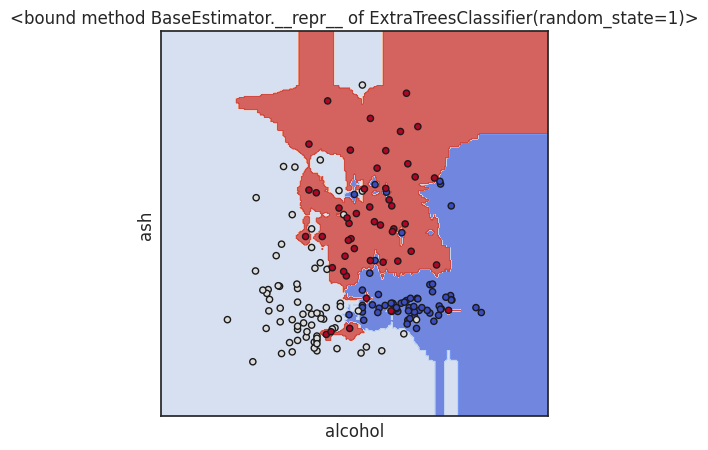

In [ ]:
plot_cl(ExtraTreesClassifier(random_state=1))

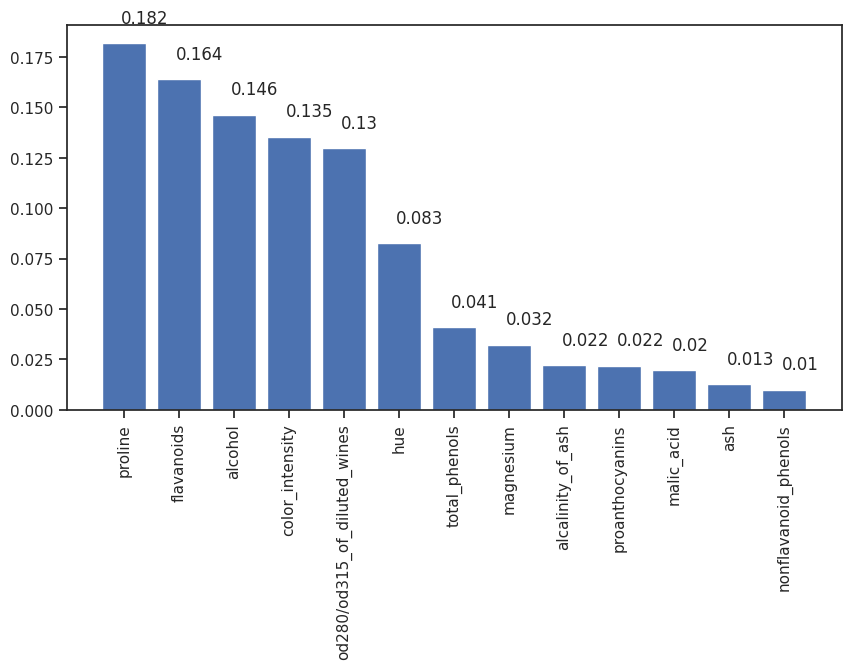

In [ ]:
wine_x_ds = pd.DataFrame(data=wine['data'], columns=wine['feature_names'])
wine_rf_cl = RandomForestClassifier(random_state=1)
wine_rf_cl.fit(wine_x_ds, wine.target)
_,_ = draw_feature_importances(wine_rf_cl, wine_x_ds)

In [ ]:
wine_tree_cl = ExtraTreesClassifier(random_state=1)
wine_tree_cl.fit(wine_x_ds, wine.target)
_, _ = draw_feature_importances(wine_xtree_cl, wine_x_ds)

NameError: name 'wine_xtree_cl' is not defined

In [ ]:
wine_tree_cl= DecisionTreeClassifier(random_state=1)
wine_tree_cl.fit(wine_x_ds, wine.target)
_,_ = draw_feature_importances(wine_tree_cl, wine_x_ds)